In [1]:
print(1)

1


In [2]:
import sys
import asyncio
import time
import os

import numpy as np
import matplotlib.pyplot as plt

from lsst.rapid.analysis.focusAnalysis import NonSpectralFocusAnalyzer

CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS AT_O_20210323_000295: 'MJD-OBS not found'
Found multiple max pixels or star is saturated, usign CoM for centroid
Centroid adjusted by [-0.15560054  0.74784073] pixels
quickLookExp not found for 296, reproducing...
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
Found multiple max pixels or star is saturated, usign CoM for centroid
Centroid adjusted by [0.37317902 0.40975662] pixels
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS AT_O_20210323_000297: 'MJD-OBS not found'
Found multiple max pixels or star is saturated, usign CoM for centroid

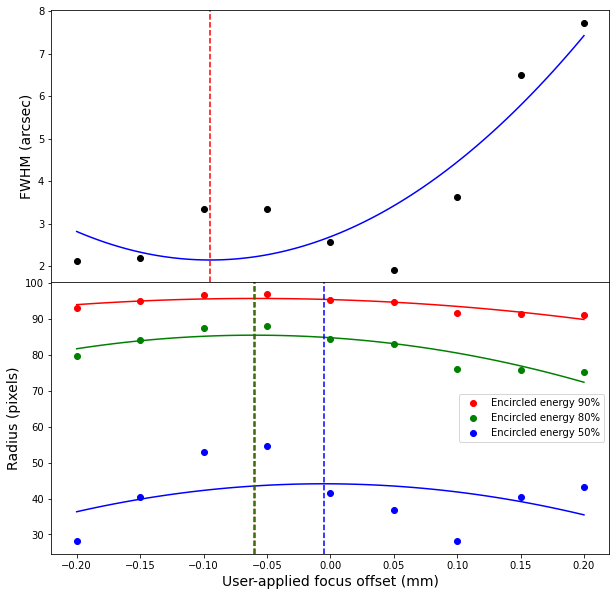

In [4]:
repoDir = '/project/shared/auxTel/rerun/quickLook/'
analyzer = NonSpectralFocusAnalyzer(repoDir)
%matplotlib inline
dayObs = '2021-03-23'
seqNums = [s for s in range(295, 303+1)]
offset = analyzer.run(dayObs, seqNums)

In [5]:
offset

{'fwhmFitMin': -0.09489158949778505,
 'ee90FitMin': -0.059372187011893125,
 'ee80FitMin': -0.0602382570295301,
 'ee50FitMin': -0.005291036198213693}

In [ ]:
from lsst.rapid.analysis.focusAnalysis import SpectralFocusAnalyzer
repoDir = '/project/shared/auxTel/'
analyzer = SpectralFocusAnalyzer(repoDir)
%matplotlib inline
dayObs = '2021-03-11'
seqNums = [156,157,158,161,162,163,164]#range(156, 164+1)
analyzer._spectrumBoxOffsets = [1000, 1200, 1400]
analyzer.spectrumHalfWidth = 150
bestFit = analyzer.run(dayObs, seqNums, doDisplay=True)